# 2. 평가 — 그림 + 통계치 저장

`result/predictions/*.csv` 를 로드해 지표를 계산하고,
- **통계치** → `result/statistics/metrics.csv`, `stage_r2.csv`
- **그림** → `result/image/metric_bars.png`, `scatter_grid.png`, `stage_r2.png`

**지표**: R²(설명력), MAE/RMSE(오차, 작을수록↑), Spearman ρ(순위 일치도, 높을수록↑ — 상대가치 랭킹).

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from util import file_manager as fm, plot
from util.metric import metrics, stage_r2

preds = {p.stem: pd.read_csv(p) for p in fm.list_predictions()}
# PI-DeepONet 일단 그래프/지표에서 제외
preds = {k: v for k, v in preds.items() if "pi_deeponet" not in k}
print("loaded predictions:", list(preds.keys()))

loaded predictions: ['bench_catboost', 'bench_gbm', 'bench_lgbm', 'bench_ridge', 'bench_xgboost', 'deeponet_direct', 'deeponet_hybrid', 'deeponet_hybrid_s2don', 'xgb_hybrid']


In [2]:
# 지표 표
rows, scat = [], {}
for name, df in preds.items():
    rows.append({"model": name, **metrics(df["y_true"], df["y_pred"])})
    scat[name] = (df["y_true"].values, df["y_pred"].values)
mt = pd.DataFrame(rows).set_index("model").sort_values("R2", ascending=False)
mt.to_csv(fm.stat("metrics"))
print(mt.round(4).to_string())

                           R2     MAE    RMSE  Spearman
model                                                  
deeponet_hybrid        0.7370  0.0206  0.0265    0.8675
xgb_hybrid             0.7303  0.0207  0.0269    0.8633
deeponet_hybrid_s2don  0.5973  0.0253  0.0329    0.7876
bench_ridge            0.5596  0.0270  0.0344    0.7611
bench_catboost         0.3292  0.0355  0.0424    0.5403
bench_lgbm             0.3240  0.0351  0.0426    0.5512
bench_xgboost          0.2875  0.0363  0.0437    0.5081
bench_gbm              0.2744  0.0365  0.0441    0.5190
deeponet_direct       -0.1874  0.0457  0.0564    0.3056


In [3]:
# stage별 R² (하이브리드)
st = {name: stage_r2(df) for name, df in preds.items() if stage_r2(df) is not None}
sdf = pd.DataFrame(st).T
sdf.to_csv(fm.stat("stage_r2"))
print(sdf.round(3).to_string())

                       stage1_MC_R2  stage2_resid_R2  final_FAIR_R2
deeponet_hybrid               0.988            0.492          0.737
deeponet_hybrid_s2don         0.988            0.219          0.597
xgb_hybrid                    0.895            0.492          0.730


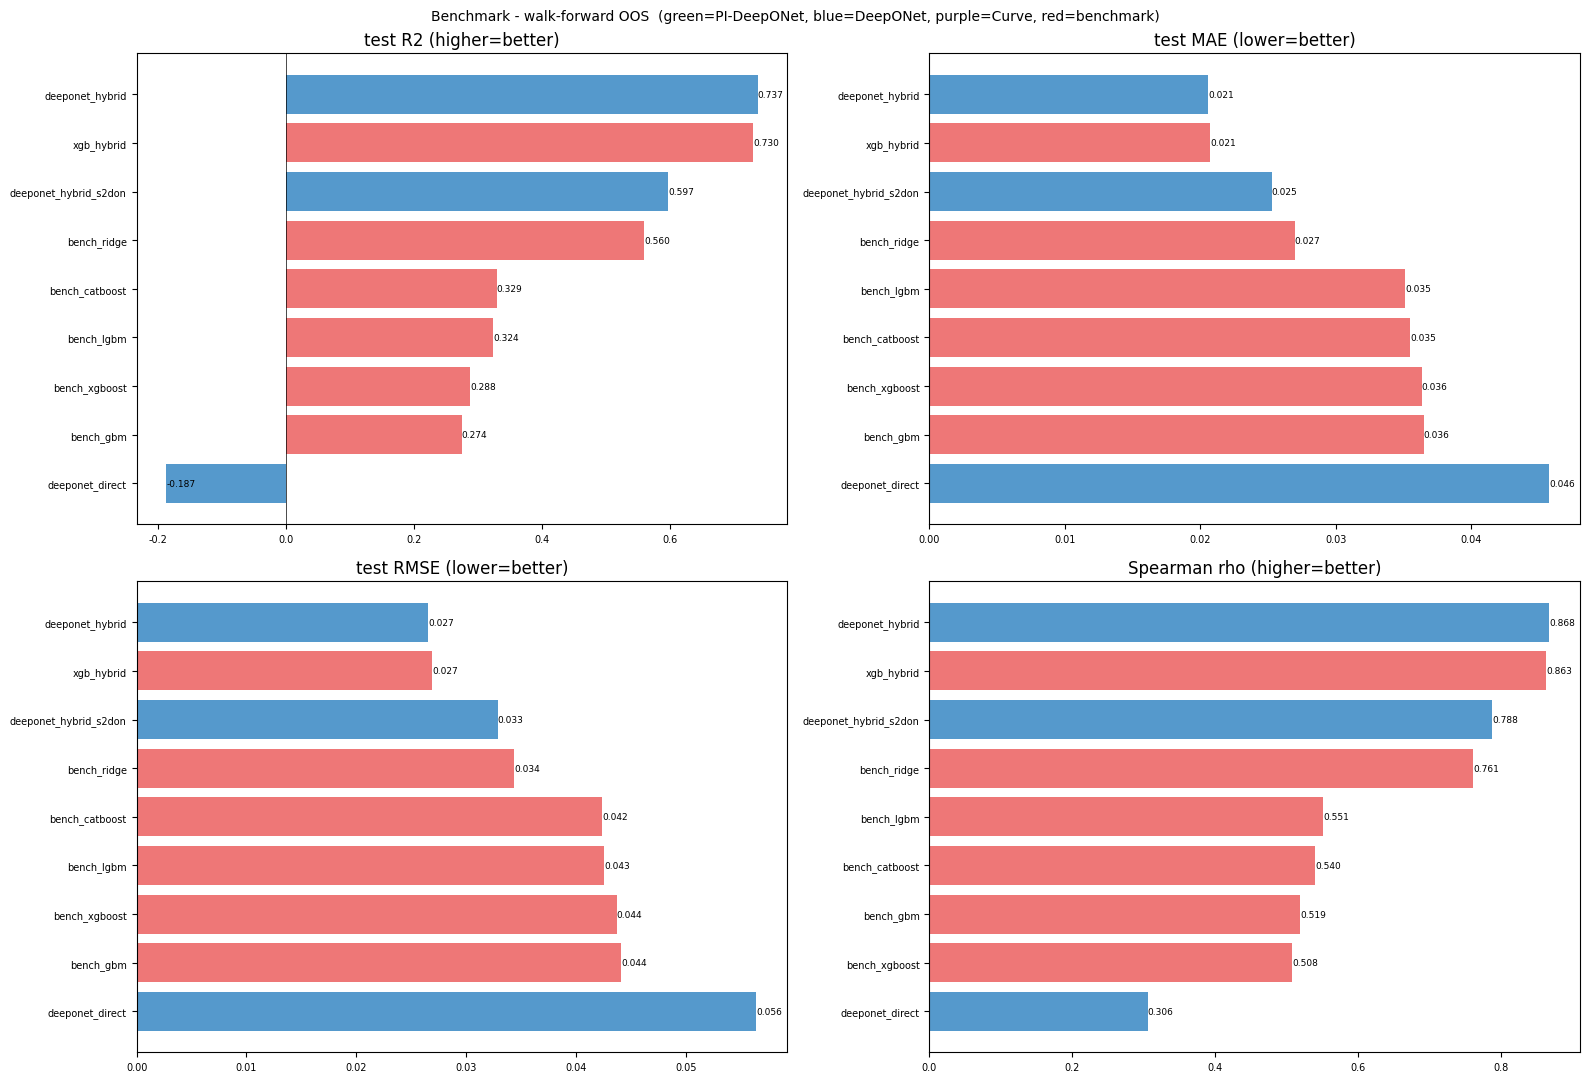

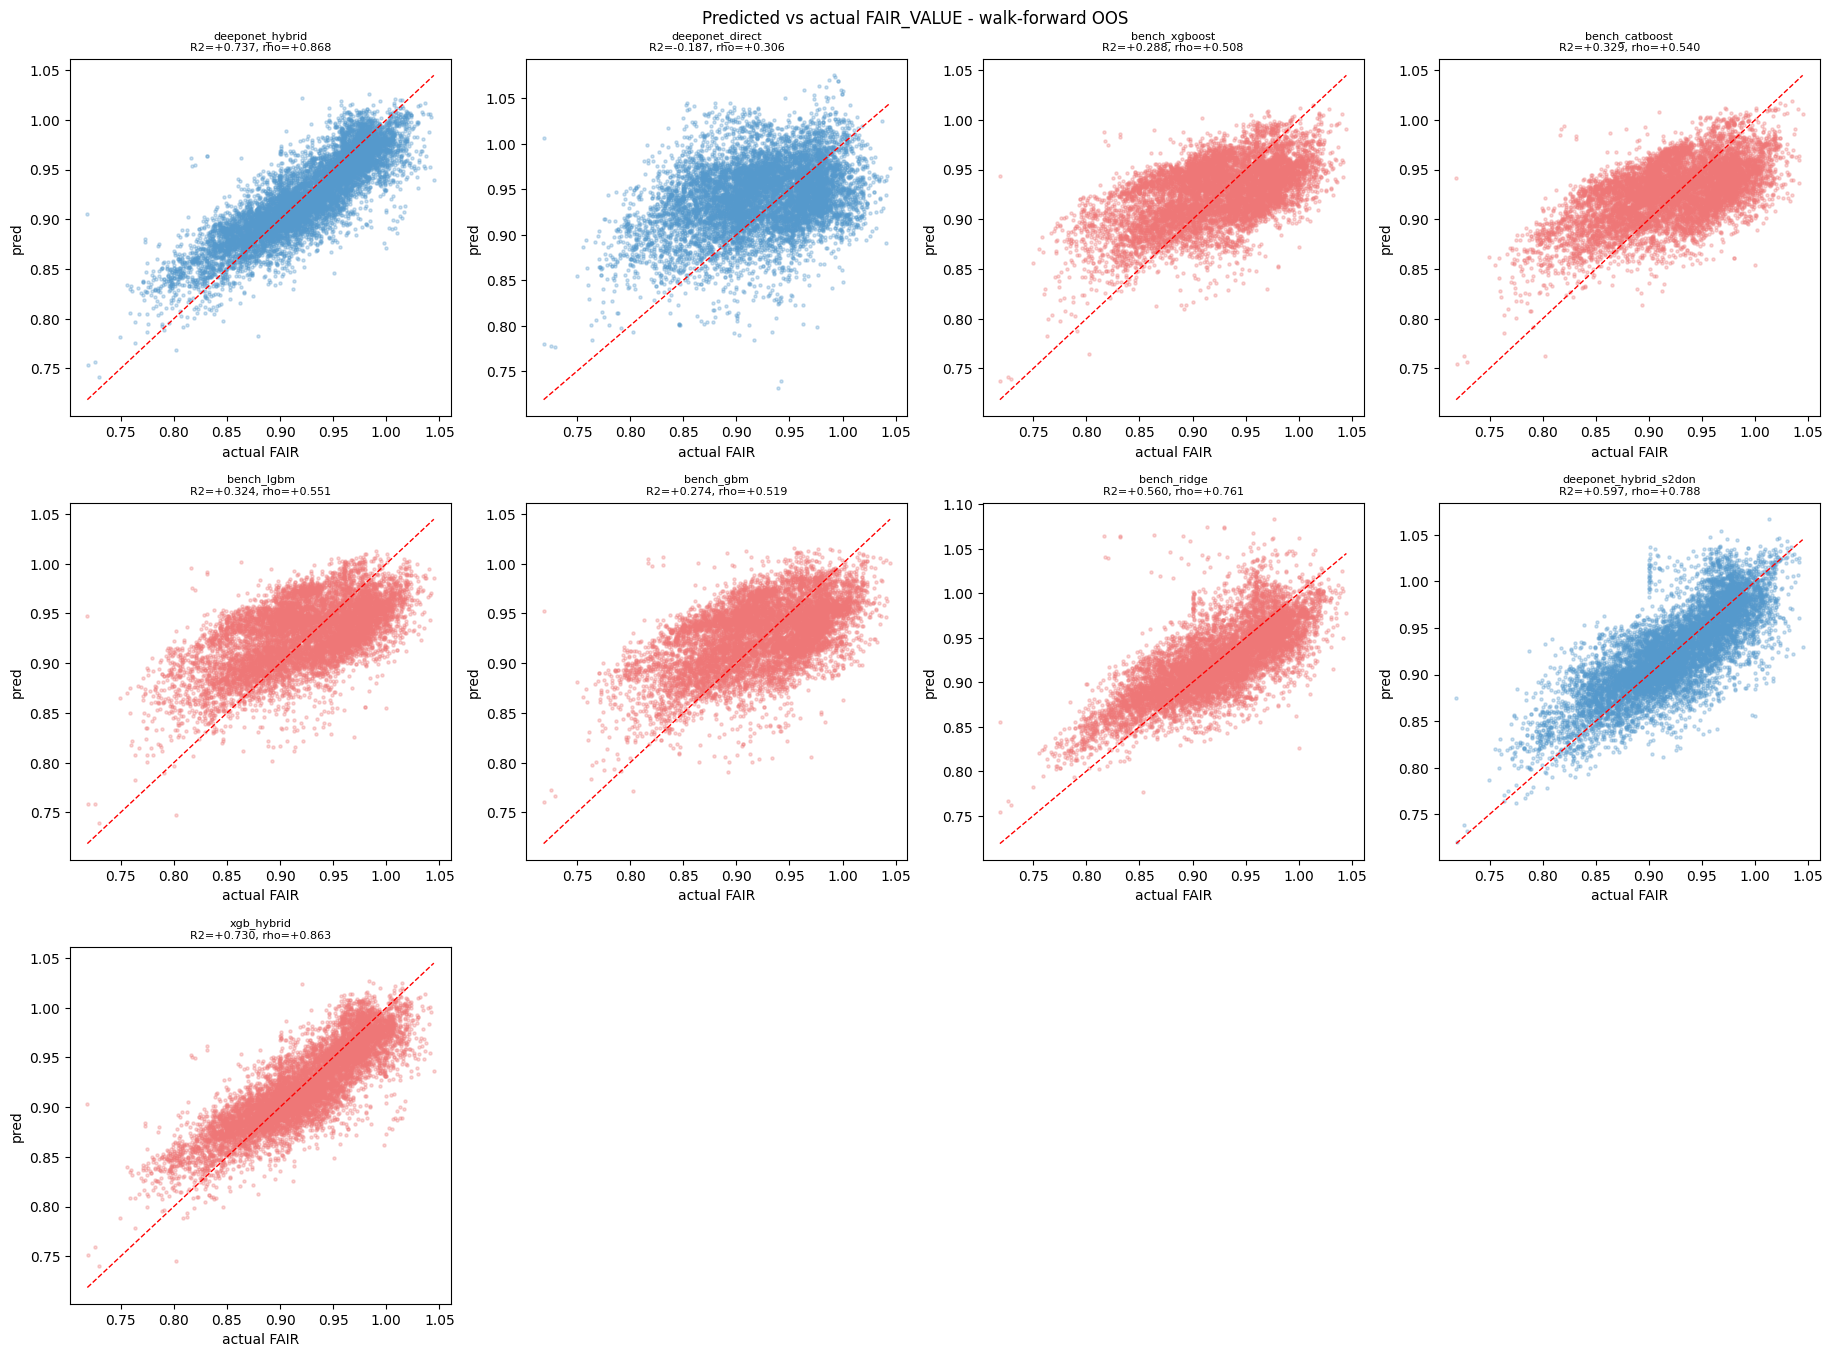

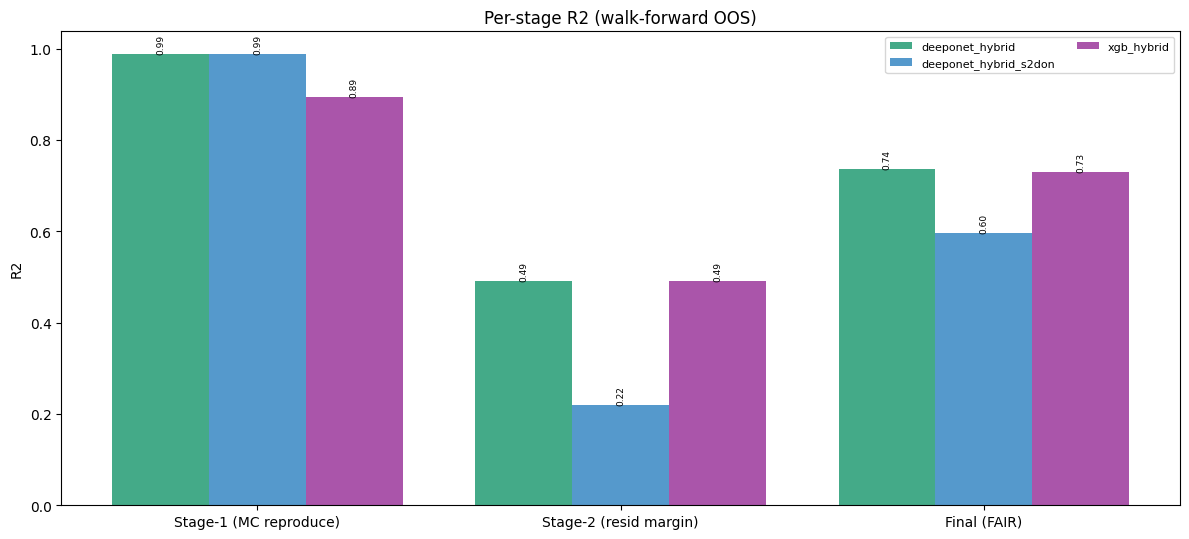

saved images -> ['inference_speed.png', 'metric_bars.png', 'scatter_grid.png', 'stage_r2.png']
saved stats  -> ['inference_speed.csv', 'metrics.csv', 'stage_r2.csv']


In [4]:
# 그림 저장 + 표시
ORDER = [
    "pi_deeponet_hybrid",
    "deeponet_hybrid",
    "deeponet_direct",
    "deeponet_curve_hybrid",
    "deeponet_curve_direct",
    "bench_xgboost",
    "bench_catboost",
    "bench_lgbm",
    "bench_gbm",
    "bench_ridge",
]
order = [m for m in ORDER if m in scat] + [m for m in scat if m not in ORDER]

plot.metric_bars(mt, fm.image("metric_bars"))
plot.scatter_grid(scat, order=order, path=fm.image("scatter_grid"))
if len(sdf):
    plot.stage_r2_bar(sdf, fm.image("stage_r2"))
plt.show()
print("saved images ->", [p.name for p in sorted(fm.IMAGE.glob("*.png"))])
print("saved stats  ->", [p.name for p in sorted(fm.STAT.glob("*.csv"))])

                         kind     n  batch_ms  per_product_us  products_per_sec
model                                                                          
deeponet_direct        direct  2315      0.50            0.22        4606048.42
deeponet_hybrid_s2don  hybrid  2315      0.88            0.38        2640734.63
bench_catboost         direct  2315      2.55            1.10         906953.97
bench_ridge            direct  2315      2.91            1.26         796381.03
bench_xgboost          direct  2315      6.44            2.78         359622.82
deeponet_hybrid        hybrid  2315      7.27            3.14         318488.86
xgb_hybrid             hybrid  2315      8.14            3.52         284281.04
bench_lgbm             direct  2315      9.04            3.91         256014.69
bench_gbm              direct  2315     11.14            4.81         207795.71


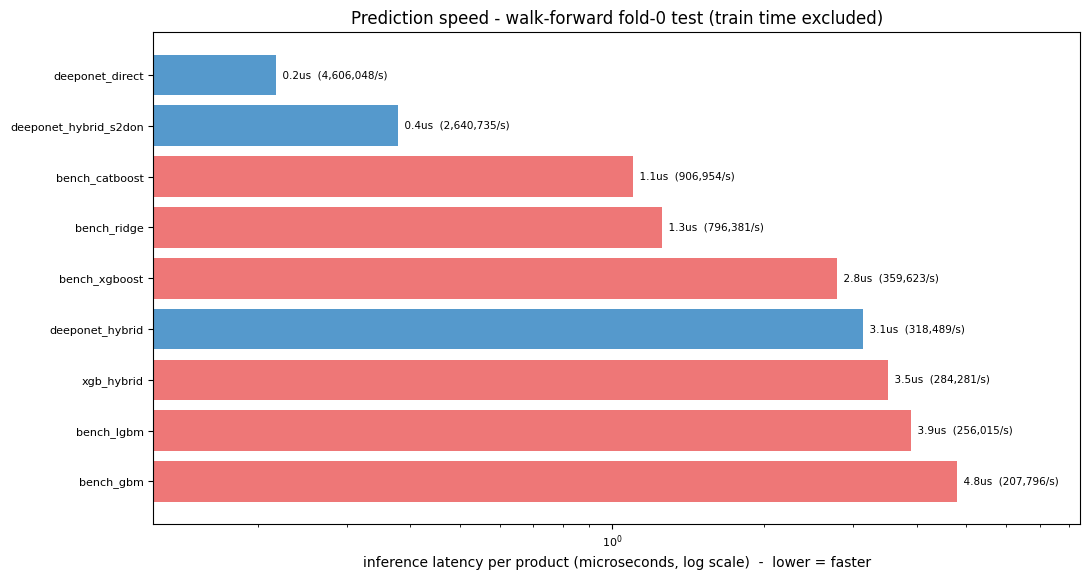

saved -> inference_speed.png | inference_speed.csv


In [5]:
# 예측(추론) 속도 측정 + 그래프  (학습 시간 제외, fold-0 test 기준)
from util import utils, speed
from module import data as _data
cfg = utils.load_config()
Dspd = _data.load(cfg)
spd = speed.measure(Dspd, cfg)
spd.to_csv(fm.stat("inference_speed"))
print(spd.round(2).to_string())
plot.speed_bar(spd, fm.image("inference_speed"))
plt.show()
print("saved ->", fm.image("inference_speed").name, "|", fm.stat("inference_speed").name)